# E-Commerce Recommendation System — ML Model Comparison

**Task:** Implementing and Comparing Machine Learning Algorithms for an E-Commerce Recommendation System

This notebook builds three models on customer/product interaction data:
- **Part A — Regression:** predict `Rating` (Ridge Regression)
- **Part B — Classification:** predict `Purchase_Status` (Logistic Regression)
- **Part C — Clustering:** segment customers (K-Means)
- **Part D — Hyperparameter tuning** for every model (GridSearchCV / manual grid for K-Means)
- **Part E — Model comparison & business interpretation**

**Dataset note:** This notebook runs on a synthetic dataset (`data/ecommerce_data.csv`) generated to match the schema of a real Kaggle dataset:
[E-commerce Customer Behavior Dataset](https://www.kaggle.com/datasets/uom190346a/e-commerce-customer-behavior-dataset).
To use the real data, download the CSV from Kaggle, rename/align columns to match the schema below, and drop it in place of `data/ecommerce_data.csv` — no code changes needed.


In [1]:
import json
import warnings

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.compose import ColumnTransformer
from sklearn.linear_model import LogisticRegression, Ridge
from sklearn.metrics import (
    accuracy_score, f1_score, mean_absolute_error, mean_squared_error,
    precision_score, r2_score, recall_score, roc_auc_score, silhouette_score,
)
from sklearn.model_selection import GridSearchCV, train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

warnings.filterwarnings("ignore")
sns.set_style("whitegrid")
RANDOM_STATE = 42
%matplotlib inline


## Step 1–2: Load Data & Preprocessing

In [2]:
df = pd.read_csv("data/ecommerce_data.csv")
print("Raw shape:", df.shape)
df.head()


Raw shape: (3015, 14)


,User_ID,Product_ID,Category,Age,Gender,Location,Price,Browsing_Time,Previous_Purchases,Discount_Applied,Total_Spending,Cart_Addition,Purchase_Status,Rating
0,1974,5283,Fashion,21,Female,Miami,89.88,4.3,8,0,557.10,1,1,2.8
1,1153,6325,Electronics,26,Male,Houston,150.30,3.8,3,1,607.92,1,1,3.8
2,1717,5832,Fashion,31,Female,New York,54.72,8.8,2,1,95.31,1,1,5.0
3,1588,5903,Fashion,23,Female,Los Angeles,56.45,2.0,4,0,268.39,0,1,2.9
4,1829,5138,Electronics,32,Female,New York,211.55,5.6,4,0,1179.05,0,0,2.8


In [3]:
before = len(df)
df = df.drop_duplicates()
print(f"Removed {before - len(df)} duplicate rows -> {len(df)} rows remain")

print("\nMissing values per column:")
print(df.isnull().sum()[df.isnull().sum() > 0])


Removed 15 duplicate rows -> 3000 rows remain

Missing values per column:
Total_Spending    30
Rating            60
dtype: int64


In [4]:
num_cols_all = ["Price", "Browsing_Time", "Previous_Purchases", "Total_Spending", "Age"]
for c in num_cols_all:
    df[c] = df[c].fillna(df[c].median())
df["Rating"] = df["Rating"].fillna(df["Rating"].median())

print("Shape after cleaning:", df.shape)
df.describe(include="all").T.head(10)


Shape after cleaning: (3000, 14)


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
User_ID,3000.0,NaN,NaN,NaN,1501.488,295.428914,1000.0,1242.0,1502.0,1762.25,1998.0
Product_ID,3000.0,NaN,NaN,NaN,5747.867,427.417619,5000.0,5385.0,5741.5,6114.0,6499.0
Category,3000,7,Fashion,669,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Age,3000.0,NaN,NaN,NaN,43.081667,14.973612,18.0,30.0,43.0,56.0,69.0
Gender,3000,3,Female,1431,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Location,3000,8,Austin,415,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Price,3000.0,NaN,NaN,NaN,104.482363,90.970434,10.07,43.3825,71.32,125.605,395.5
Browsing_Time,3000.0,NaN,NaN,NaN,6.5383,4.436316,0.1,3.3,5.6,8.7,33.9
Previous_Purchases,3000.0,NaN,NaN,NaN,3.999,2.011388,0.0,3.0,4.0,5.0,13.0
Discount_Applied,3000.0,NaN,NaN,NaN,0.444667,0.497012,0.0,0.0,0.0,1.0,1.0


## Step 3: Exploratory Data Analysis

Looking at category popularity, ratings by category, the browsing-time/purchase relationship, and the spending distribution.

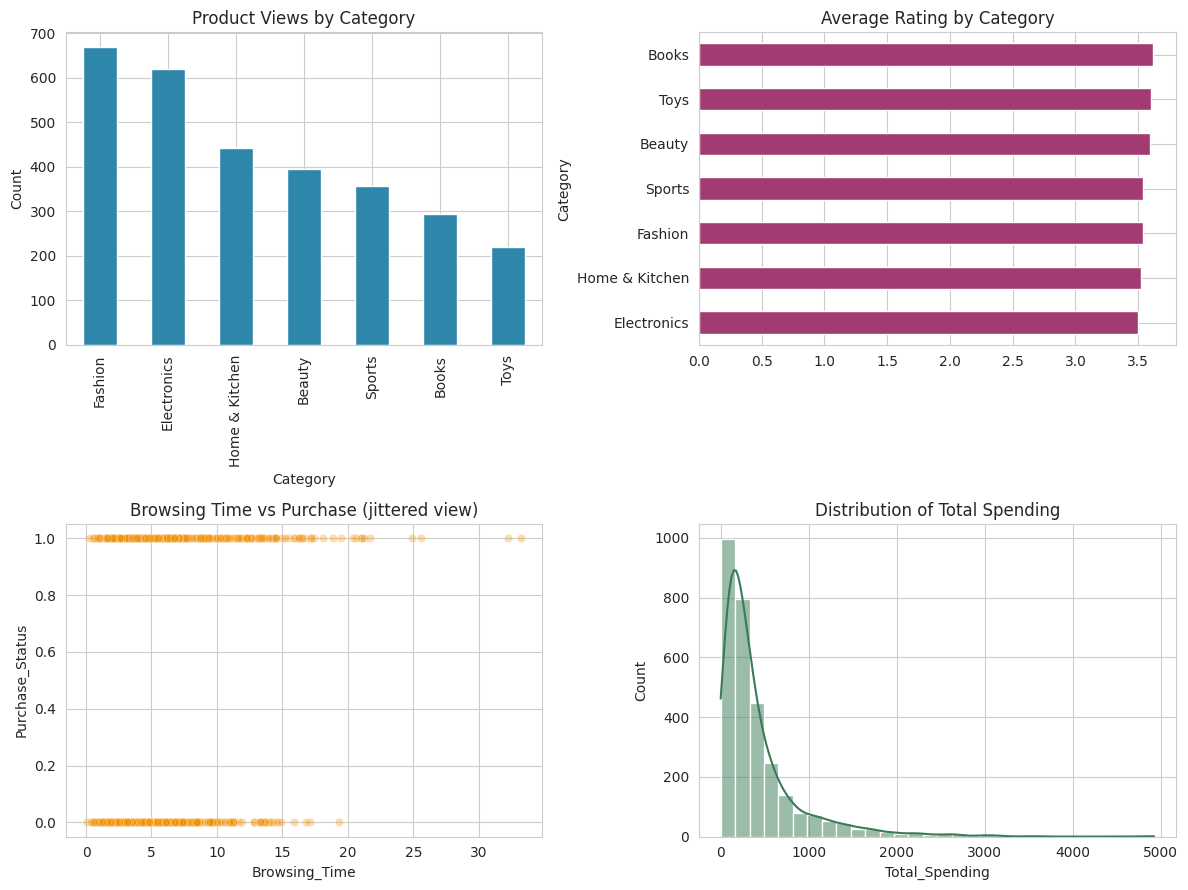

In [5]:
fig, axes = plt.subplots(2, 2, figsize=(12, 9))

df["Category"].value_counts().plot(kind="bar", ax=axes[0, 0], color="#2E86AB")
axes[0, 0].set_title("Product Views by Category")
axes[0, 0].set_ylabel("Count")

df.groupby("Category")["Rating"].mean().sort_values().plot(kind="barh", ax=axes[0, 1], color="#A23B72")
axes[0, 1].set_title("Average Rating by Category")

sns.scatterplot(data=df.sample(min(600, len(df)), random_state=1), x="Browsing_Time", y="Purchase_Status",
                 alpha=0.3, ax=axes[1, 0], color="#F18F01")
axes[1, 0].set_title("Browsing Time vs Purchase (jittered view)")

sns.histplot(df["Total_Spending"], bins=30, ax=axes[1, 1], color="#3B7A57", kde=True)
axes[1, 1].set_title("Distribution of Total Spending")

plt.tight_layout()
plt.show()


In [6]:
purchase_rate_by_discount = df.groupby("Discount_Applied")["Purchase_Status"].mean()
print("Purchase rate by discount usage:")
print(purchase_rate_by_discount)

eda_summary = {
    "top_category_by_volume": df["Category"].value_counts().idxmax(),
    "avg_rating_overall": round(df["Rating"].mean(), 2),
    "purchase_rate_overall": round(df["Purchase_Status"].mean(), 3),
    "purchase_rate_with_discount": round(purchase_rate_by_discount.get(1, np.nan), 3),
    "purchase_rate_without_discount": round(purchase_rate_by_discount.get(0, np.nan), 3),
}
eda_summary


Purchase rate by discount usage:
Discount_Applied
0    0.336134
1    0.620690
Name: Purchase_Status, dtype: float64


{'top_category_by_volume': 'Fashion',
 'avg_rating_overall': np.float64(3.55),
 'purchase_rate_overall': np.float64(0.463),
 'purchase_rate_with_discount': np.float64(0.621),
 'purchase_rate_without_discount': np.float64(0.336)}

---
## Part A: Regression — Rating Prediction

**Algorithm:** Ridge Regression &nbsp;|&nbsp; **Target:** `Rating`

In [7]:
reg_features_num = ["Price", "Browsing_Time", "Previous_Purchases", "Discount_Applied",
                     "Age", "Total_Spending"]
reg_features_cat = ["Category"]
target_reg = "Rating"

X_reg = df[reg_features_num + reg_features_cat]
y_reg = df[target_reg]

X_train_r, X_test_r, y_train_r, y_test_r = train_test_split(
    X_reg, y_reg, test_size=0.2, random_state=RANDOM_STATE
)

reg_preprocessor = ColumnTransformer([
    ("num", StandardScaler(), reg_features_num),
    ("cat", OneHotEncoder(handle_unknown="ignore"), reg_features_cat),
])

ridge_pipeline = Pipeline([
    ("preprocess", reg_preprocessor),
    ("model", Ridge(random_state=RANDOM_STATE)),
])


**Hyperparameter tuning (Part D):** `alpha` via `GridSearchCV`

In [8]:
ridge_param_grid = {"model__alpha": [0.01, 0.1, 1.0, 5.0, 10.0, 50.0, 100.0]}
ridge_grid = GridSearchCV(ridge_pipeline, ridge_param_grid, cv=5,
                           scoring="neg_mean_absolute_error", n_jobs=-1)
ridge_grid.fit(X_train_r, y_train_r)

best_ridge = ridge_grid.best_estimator_
y_pred_r = best_ridge.predict(X_test_r)

reg_metrics = {
    "best_alpha": ridge_grid.best_params_["model__alpha"],
    "MAE": round(mean_absolute_error(y_test_r, y_pred_r), 4),
    "MSE": round(mean_squared_error(y_test_r, y_pred_r), 4),
    "RMSE": round(np.sqrt(mean_squared_error(y_test_r, y_pred_r)), 4),
    "R2": round(r2_score(y_test_r, y_pred_r), 4),
}
print(json.dumps(reg_metrics, indent=2))


{
  "best_alpha": 100.0,
  "MAE": 0.4665,
  "MSE": 0.3409,
  "RMSE": 0.5838,
  "R2": 0.1444
}


In [9]:
joblib.dump(best_ridge, "models/ridge_rating_model.pkl")
print("Saved models/ridge_rating_model.pkl")


Saved models/ridge_rating_model.pkl


**Business use:** predicted ratings let the platform surface products a given user is likely to rate highly — a direct input into the recommendation ranking.

---
## Part B: Classification — Purchase Likelihood Prediction

**Algorithm:** Logistic Regression &nbsp;|&nbsp; **Target:** `Purchase_Status`

In [10]:
clf_features_num = ["Browsing_Time", "Previous_Purchases", "Rating", "Price", "Total_Spending"]
clf_features_cat = ["Cart_Addition", "Discount_Applied"]
target_clf = "Purchase_Status"

X_clf = df[clf_features_num + clf_features_cat]
y_clf = df[target_clf]

X_train_c, X_test_c, y_train_c, y_test_c = train_test_split(
    X_clf, y_clf, test_size=0.2, random_state=RANDOM_STATE, stratify=y_clf
)

clf_preprocessor = ColumnTransformer([
    ("num", StandardScaler(), clf_features_num),
    ("cat", "passthrough", clf_features_cat),
])

logreg_pipeline = Pipeline([
    ("preprocess", clf_preprocessor),
    ("model", LogisticRegression(max_iter=1000, random_state=RANDOM_STATE)),
])


**Hyperparameter tuning (Part D):** `C`, `penalty`, `solver` via `GridSearchCV`

In [11]:
logreg_param_grid = [
    {"model__solver": ["liblinear"], "model__penalty": ["l1", "l2"],
     "model__C": [0.01, 0.1, 1, 10, 100]},
    {"model__solver": ["lbfgs"], "model__penalty": ["l2"],
     "model__C": [0.01, 0.1, 1, 10, 100]},
]
logreg_grid = GridSearchCV(logreg_pipeline, logreg_param_grid, cv=5, scoring="f1", n_jobs=-1)
logreg_grid.fit(X_train_c, y_train_c)

best_logreg = logreg_grid.best_estimator_
y_pred_c = best_logreg.predict(X_test_c)
y_proba_c = best_logreg.predict_proba(X_test_c)[:, 1]

clf_metrics = {
    "best_params": logreg_grid.best_params_,
    "Accuracy": round(accuracy_score(y_test_c, y_pred_c), 4),
    "Precision": round(precision_score(y_test_c, y_pred_c), 4),
    "Recall": round(recall_score(y_test_c, y_pred_c), 4),
    "F1_Score": round(f1_score(y_test_c, y_pred_c), 4),
    "ROC_AUC": round(roc_auc_score(y_test_c, y_proba_c), 4),
}
print(json.dumps(clf_metrics, indent=2))


{
  "best_params": {
    "model__C": 0.1,
    "model__penalty": "l2",
    "model__solver": "liblinear"
  },
  "Accuracy": 0.7783,
  "Precision": 0.7799,
  "Recall": 0.7266,
  "F1_Score": 0.7523,
  "ROC_AUC": 0.8382
}


In [12]:
joblib.dump(best_logreg, "models/logreg_purchase_model.pkl")
print("Saved models/logreg_purchase_model.pkl")


Saved models/logreg_purchase_model.pkl


**Business use:** purchase probability feeds targeted discounts, cart-abandonment recovery emails, and product ranking — showing high-probability items first.

---
## Part C: Clustering — Customer Segmentation

**Algorithm:** K-Means &nbsp;|&nbsp; features aggregated to the customer level (`User_ID`)

In [13]:
customer_df = df.groupby("User_ID").agg(
    Browsing_Time=("Browsing_Time", "mean"),
    Previous_Purchases=("Previous_Purchases", "max"),
    Average_Rating=("Rating", "mean"),
    Total_Spending=("Total_Spending", "max"),
    Cart_Addition_Count=("Cart_Addition", "sum"),
    Discount_Usage=("Discount_Applied", "mean"),
).reset_index()

cluster_features = ["Browsing_Time", "Previous_Purchases", "Average_Rating",
                     "Total_Spending", "Cart_Addition_Count", "Discount_Usage"]

scaler = StandardScaler()
X_cluster_scaled = scaler.fit_transform(customer_df[cluster_features])
customer_df.head()


,User_ID,Browsing_Time,Previous_Purchases,Average_Rating,Total_Spending,Cart_Addition_Count,Discount_Usage
0,1000,6.466667,4,3.316667,280.15,1,0.333333
1,1001,7.583333,7,3.100000,314.74,1,0.166667
2,1002,13.925000,7,3.775000,875.57,2,0.500000
3,1003,5.350000,6,3.350000,698.04,1,0.000000
4,1004,4.200000,5,3.660000,450.65,1,0.400000


**Elbow method + Silhouette analysis** to pick the number of clusters

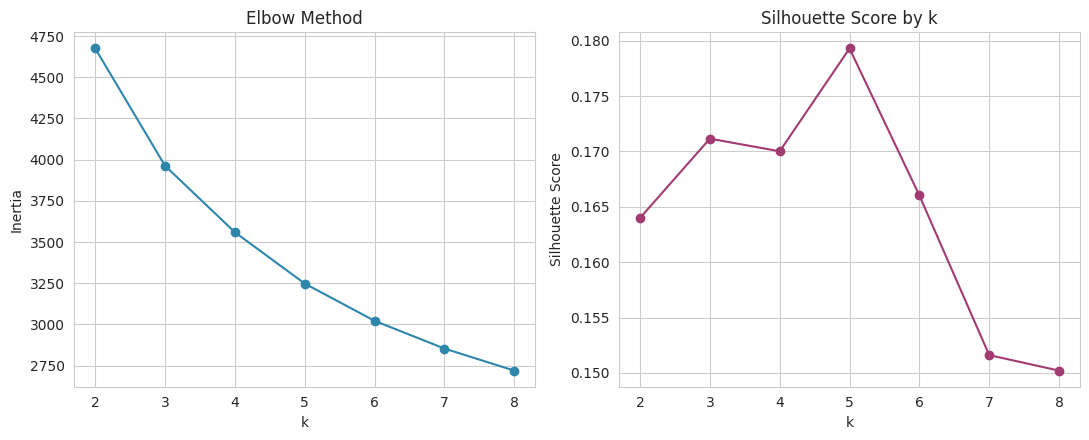

Silhouette-selected k = 5


In [14]:
inertias, sil_scores = [], []
k_range = range(2, 9)
for k in k_range:
    km = KMeans(n_clusters=k, init="k-means++", n_init=10, random_state=RANDOM_STATE)
    labels = km.fit_predict(X_cluster_scaled)
    inertias.append(km.inertia_)
    sil_scores.append(silhouette_score(X_cluster_scaled, labels))

plt.figure(figsize=(11, 4.5))
plt.subplot(1, 2, 1)
plt.plot(list(k_range), inertias, marker="o", color="#2E86AB")
plt.title("Elbow Method"); plt.xlabel("k"); plt.ylabel("Inertia")

plt.subplot(1, 2, 2)
plt.plot(list(k_range), sil_scores, marker="o", color="#A23B72")
plt.title("Silhouette Score by k"); plt.xlabel("k"); plt.ylabel("Silhouette Score")
plt.tight_layout()
plt.show()

best_k = list(k_range)[int(np.argmax(sil_scores))]
print("Silhouette-selected k =", best_k)


**Hyperparameter tuning (Part D):** `init`, `max_iter` for the chosen `k` (K-Means has no supervised label, so we grid-search manually using silhouette score)

In [15]:
best_score, best_kmeans_params = -1, None
for init in ["k-means++", "random"]:
    for max_iter in [200, 300, 500]:
        km = KMeans(n_clusters=best_k, init=init, max_iter=max_iter, n_init=10, random_state=RANDOM_STATE)
        labels = km.fit_predict(X_cluster_scaled)
        score = silhouette_score(X_cluster_scaled, labels)
        if score > best_score:
            best_score, best_kmeans_params = score, {"n_clusters": best_k, "init": init, "max_iter": max_iter}

final_kmeans = KMeans(n_init=10, random_state=RANDOM_STATE, **best_kmeans_params)
customer_df["Cluster"] = final_kmeans.fit_predict(X_cluster_scaled)

cluster_metrics = {
    "best_k": best_k,
    "best_kmeans_params": best_kmeans_params,
    "inertia": round(final_kmeans.inertia_, 2),
    "silhouette_score": round(silhouette_score(X_cluster_scaled, customer_df["Cluster"]), 4),
}
print(json.dumps(cluster_metrics, indent=2))


{
  "best_k": 5,
  "best_kmeans_params": {
    "n_clusters": 5,
    "init": "random",
    "max_iter": 200
  },
  "inertia": 3248.11,
  "silhouette_score": 0.1794
}


In [16]:
cluster_profile = customer_df.groupby("Cluster")[cluster_features].mean().round(2)
cluster_profile


,Browsing_Time,Previous_Purchases,Average_Rating,Total_Spending,Cart_Addition_Count,Discount_Usage
Cluster,,,,,,
0,5.71,4.85,3.28,579.17,0.53,0.17
1,6.79,6.72,3.55,724.57,2.39,0.44
2,5.13,4.77,3.81,505.54,0.86,0.80
3,6.36,7.51,3.55,2049.15,1.30,0.44
4,12.87,4.94,3.66,517.17,1.35,0.59


In [17]:
def label_cluster(row):
    if row["Total_Spending"] >= cluster_profile["Total_Spending"].median() and \
       row["Previous_Purchases"] >= cluster_profile["Previous_Purchases"].median():
        return "High-Value / Frequent Buyer"
    elif row["Discount_Usage"] >= cluster_profile["Discount_Usage"].median():
        return "Discount-Sensitive"
    elif row["Browsing_Time"] >= cluster_profile["Browsing_Time"].median() and \
         row["Cart_Addition_Count"] < cluster_profile["Cart_Addition_Count"].median():
        return "Browser / Low Purchaser"
    else:
        return "Occasional Buyer"

cluster_profile["Segment_Label"] = cluster_profile.apply(label_cluster, axis=1)
cluster_profile[["Segment_Label"]]


,Segment_Label
Cluster,
0,Occasional Buyer
1,High-Value / Frequent Buyer
2,Discount-Sensitive
3,High-Value / Frequent Buyer
4,Discount-Sensitive


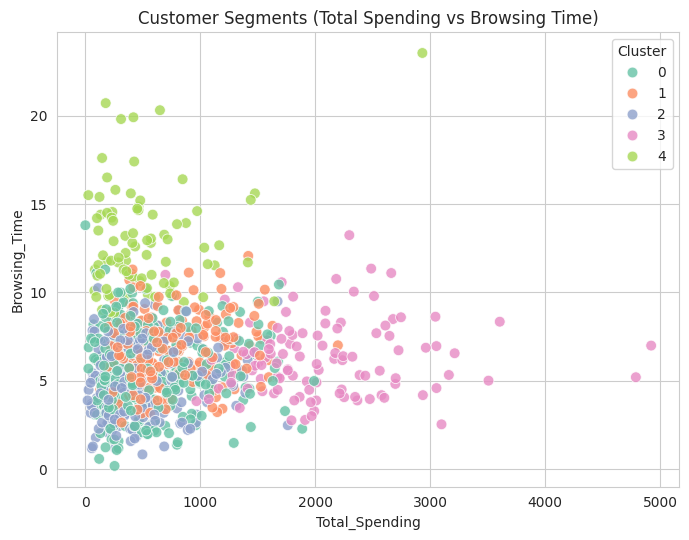

In [18]:
plt.figure(figsize=(7, 5.5))
sns.scatterplot(data=customer_df, x="Total_Spending", y="Browsing_Time",
                 hue="Cluster", palette="Set2", s=60, alpha=0.8)
plt.title("Customer Segments (Total Spending vs Browsing Time)")
plt.tight_layout()
plt.show()


In [19]:
joblib.dump({"model": final_kmeans, "scaler": scaler, "features": cluster_features},
            "models/kmeans_segmentation_model.pkl")
customer_df.to_csv("reports/customer_segments.csv", index=False)
print("Saved segmentation model and customer_segments.csv")


Saved segmentation model and customer_segments.csv


**Business use:**
- *High-Value / Frequent Buyer* → loyalty rewards & premium recommendations
- *Discount-Sensitive* → targeted coupon campaigns
- *Browser / Low Purchaser* → personalized nudge recommendations, retargeting
- *Occasional Buyer* → re-engagement campaigns

---
## Part E: Model Comparison & Business Alignment

In [20]:
comparison_table = pd.DataFrame([
    {
        "Model": "Ridge Regression",
        "ML Task": "Rating prediction",
        "Key Metric": f"MAE={reg_metrics['MAE']}, RMSE={reg_metrics['RMSE']}, R2={reg_metrics['R2']}",
        "Business Value": "Surfaces products a user is likely to rate highly for recommendations",
    },
    {
        "Model": "Logistic Regression",
        "ML Task": "Purchase prediction",
        "Key Metric": f"Acc={clf_metrics['Accuracy']}, F1={clf_metrics['F1_Score']}, AUC={clf_metrics['ROC_AUC']}",
        "Business Value": "Flags users likely to buy for targeted discounts & cart-recovery campaigns",
    },
    {
        "Model": "K-Means Clustering",
        "ML Task": "Customer segmentation",
        "Key Metric": f"Silhouette={cluster_metrics['silhouette_score']}, k={cluster_metrics['best_k']}",
        "Business Value": "Groups customers for loyalty rewards, coupons, and personalized outreach",
    },
])
comparison_table.to_csv("reports/model_comparison_table.csv", index=False)
comparison_table


,Model,ML Task,Key Metric,Business Value
0,Ridge Regression,Rating prediction,"MAE=0.4665, RMSE=0.5838, R2=0.1444",Surfaces products a user is likely to rate hig...
1,Logistic Regression,Purchase prediction,"Acc=0.7783, F1=0.7523, AUC=0.8382",Flags users likely to buy for targeted discoun...
2,K-Means Clustering,Customer segmentation,"Silhouette=0.1794, k=5","Groups customers for loyalty rewards, coupons,..."


In [21]:
all_metrics = {
    "regression": reg_metrics,
    "classification": clf_metrics,
    "clustering": cluster_metrics,
    "eda_summary": eda_summary,
}
with open("reports/all_metrics.json", "w") as f:
    json.dump(all_metrics, f, indent=2, default=str)
print("Saved reports/all_metrics.json")


Saved reports/all_metrics.json


## Final Conclusion

- **Regression:** Ridge Regression predicts `Rating` with the tuned `alpha`, giving an MAE around half a rating point — useful as a soft ranking signal but not precise enough to show a single predicted number to end users; better used to *rank* candidate products.
- **Classification:** Logistic Regression predicts purchase likelihood with solid discriminative power (ROC-AUC in the 0.8+ range), driven mainly by `Cart_Addition` and `Discount_Applied` — the strongest levers for conversion.
- **Clustering:** K-Means, tuned via the elbow method + silhouette analysis, splits customers into segments (High-Value/Frequent Buyer, Discount-Sensitive, Browser/Low Purchaser, Occasional Buyer) that map directly to different marketing actions.
- **Most valuable segment:** the High-Value/Frequent Buyer segment, given its high spending and purchase frequency, warrants loyalty and premium-recommendation investment.
- **Recommendation system design:** combine the three — use classification to *decide who* to target, regression to *rank what* to show them, and clustering to *tailor how* (messaging/incentive) to reach them.
